# Part 1 - Understanding the fMRI file

**Goal of this part:** open one fMRI file, understand what is inside it, and look at a brain.

That's all. No EEG yet, no machine learning, no processing scripts. Just: what *is* this file?

---

### The one-sentence version

An fMRI file is a **stack of 3D photographs of a brain, taken one after another over time.**

Everything else in this notebook is unpacking that sentence.

---

### How to run this notebook

Click on the first grey code cell below, then press **Shift + Enter**. That runs the cell and
moves to the next one. Keep pressing Shift + Enter to work your way down.

If a cell prints an error, stop and read the error - don't keep going. The most common one is a
missing package, which the next cell fixes.

## Step 1 - Install the tools we need

We only need three things to look at a brain scan:

| package | what it does for us |
|---|---|
| `nibabel` | knows how to open `.nii.gz` brain-scan files |
| `numpy` | handles big grids of numbers (the scan is a big grid of numbers) |
| `matplotlib` | draws pictures |

Run the cell below **once**. If they are already installed it will just say so and finish quickly.

In [25]:
# The "!" at the start tells Jupyter to run this as a command-line command, not Python.
# "-q" means quiet: don't print pages of installation logs.
%pip install -q nibabel numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Step 2 - Load the tools into this notebook

Installing a package puts it on your computer. **Importing** it makes it usable in *this* notebook.
You have to import in every new notebook, even if it's already installed.

In [26]:
# "import X as Y" means: load package X, and let me refer to it by the short name Y.
# These short names (np, plt) are near-universal conventions - you'll see them everywhere.

import numpy as np                # np  -> working with grids of numbers
import matplotlib.pyplot as plt   # plt -> drawing pictures
import nibabel as nib             # nib -> opening .nii.gz brain files

from pathlib import Path          # Path -> a nicer way to write file paths than plain strings

# Make the pictures a bit sharper. Purely cosmetic.
plt.rcParams["figure.dpi"] = 110

# If this prints without an error, everything loaded correctly.
print("All tools loaded.")
print("nibabel version:", nib.__version__)

All tools loaded.
nibabel version: 5.4.2


## Step 3 - Find an fMRI file on your disk

Your data is currently at `E:\EEG_to_FMRI`, and the fMRI scans are buried a few folders deep
inside `fMRI\fMRI\<subject number>\`.

Rather than making you type an exact path, the cell below **searches** for the files. It looks
for anything ending in `_cross.nii.gz` anywhere under your data folder.

Why that pattern? Because every subject has two brain files:

- `..._nw_mepi_rest_with_cross.nii.gz` <- the **functional** scan. Brain *activity* over time. This is what we want.
- `..._fl3D_t1_sag_fun_defaced.nii.gz` <- a **structural** scan. A single high-detail photo of brain *anatomy*. Not used for training.

Only the first one ends in `_cross`, so that pattern picks out exactly the files we care about.

In [27]:
# Path(...) turns a text path into a "Path object" that Python can search with.
# The r before the quotes means "raw string" - it stops Python treating the backslashes
# in a Windows path as special characters. Always use r"..." for Windows paths.
DATA_FOLDER = Path(r"E:\EEG_to_FMRI")

# .rglob() = "recursive glob" = search this folder AND every folder inside it.
# "*" is a wildcard meaning "any characters here".
# So "*_cross.nii.gz" matches any filename that ends with _cross.nii.gz
# sorted(...) puts the results in a predictable order instead of a random one.
fmri_files = sorted(DATA_FOLDER.rglob("*_cross.nii.gz"))

# len() counts how many items are in a list.
print(f"Found {len(fmri_files)} functional fMRI files.")
print()

# Loop over the list and print each one.
# enumerate() gives us a counter (i) alongside each item (f), so we can number the output.
for i, f in enumerate(fmri_files):
    # f.parent.name is the name of the folder the file sits in - which is the subject number.
    print(f"  [{i}]  subject {f.parent.name:>3}   {f.name}")

Found 32 functional fMRI files.

  [0]  subject  32   ._3_nw_mepi_rest_with_cross.nii.gz
  [1]  subject  35   ._3_nw_mepi_rest_with_cross.nii.gz
  [2]  subject  36   ._3_nw_mepi_rest_with_cross.nii.gz
  [3]  subject  37   ._3_nw_mepi_rest_with_cross.nii.gz
  [4]  subject  38   ._3_nw_mepi_rest_with_cross.nii.gz
  [5]  subject  39   ._3_nw_mepi_rest_with_cross.nii.gz
  [6]  subject  40   ._05_nw_mepi_rest_with_cross.nii.gz
  [7]  subject  42   ._3_nw_mepi_rest_with_cross.nii.gz
  [8]  subject  43   ._3_nw_mepi_rest_with_cross.nii.gz
  [9]  subject  44   ._3_nw_mepi_rest_with_cross.nii.gz
  [10]  subject  45   ._3_nw_mepi_rest_with_cross.nii.gz
  [11]  subject  46   ._3_nw_mepi_rest_with_cross.nii.gz
  [12]  subject  47   ._3_nw_mepi_rest_with_cross.nii.gz
  [13]  subject  48   ._3_nw_mepi_rest_with_cross.nii.gz
  [14]  subject  49   ._3_nw_mepi_rest_with_cross.nii.gz
  [15]  subject  50   ._3_nw_mepi_rest_with_cross.nii.gz
  [16]  subject  32   3_nw_mepi_rest_with_cross.nii.gz
  [17]  s

**Expected:** 16 files, one per subject, numbered 32 to 50 (with some gaps - 33, 34 and 41
don't exist in this dataset).

If you got 0 files, `DATA_FOLDER` is pointing at the wrong place. Fix the path and re-run.

If you got 32 files, your search also picked up the `__MACOSX` junk folders that came out of the
zip archives. Harmless for now - we'll ignore them by picking a specific file next.

## Step 4 - Pick one subject to look at

16 subjects is 16 times more than we need to understand the format. We'll work with **one**.

In [28]:
# Pick the file at position 0 in the list - i.e. the first one.
# Change this number to look at a different subject.
chosen = fmri_files[0]

print("Working with this file:")
print()
print("  full path :", chosen)
print("  subject   :", chosen.parent.name)

# .stat().st_size gives the file size in bytes.
# Dividing by 1024 twice converts bytes -> kilobytes -> megabytes.
size_mb = chosen.stat().st_size / 1024 / 1024
print(f"  size      : {size_mb:.1f} MB  (compressed - it gets much bigger once opened)")

Working with this file:

  full path : E:\EEG_to_FMRI\fMRI\__MACOSX\fMRI\32\._3_nw_mepi_rest_with_cross.nii.gz
  subject   : 32
  size      : 0.0 MB  (compressed - it gets much bigger once opened)


## Step 5 - Open the file

Opening a brain scan happens in **two separate steps**, and understanding why matters.

A `.nii.gz` file contains two different things:

1. **The header** - a small description: how big is the image, how big is a voxel in millimetres,
   which way is "up". Tiny, a few hundred bytes.
2. **The image data** - the actual numbers. Hundreds of megabytes.

`nib.load()` reads *only the header*. It does not touch the big data yet. This is deliberate -
it means you can inspect a huge file instantly without waiting for it to load.

Think of it like a library catalogue card: you read the card first to decide whether you want
the book.

In [29]:
# Some of the files we found are macOS "resource fork" copies (filenames starting with
# "._"), left over from an archive that was zipped on a Mac. They are not real gzip data,
# so nib.load() fails on them. If we happened to pick one, swap it for a real file instead.
if chosen.name.startswith("._"):
    real_chosen = next(f for f in fmri_files if not f.name.startswith("._"))
    print(f"'{chosen.name}' is a macOS junk file, not real data - using '{real_chosen.name}' instead.")
    chosen = real_chosen

# This is fast - it only reads the small header, not the image itself.
img = nib.load(chosen)

# "img" is now a nibabel image object. Let's ask it questions.
print("Opened. Type of object:", type(img).__name__)

'._3_nw_mepi_rest_with_cross.nii.gz' is a macOS junk file, not real data - using '3_nw_mepi_rest_with_cross.nii.gz' instead.
Opened. Type of object: Nifti1Image


## Step 6 - The shape: what the four numbers mean

This is the single most important cell in this notebook.

In [30]:
# .shape tells us the dimensions of the image, without loading it.
print("Shape:", img.shape)

Shape: (64, 64, 30, 300)


You should see **`(64, 64, 30, 300)`**. Four numbers. Here is what each one is:

```
        (  64  ,   64  ,   30  ,   300  )
           │        │       │       │
           │        │       │       └── TIME:  300 separate scans, taken one after another
           │        │       └────────── SLICES: each scan is 30 horizontal slices
           │        └────────────────── HEIGHT: each slice is a 64 x 64 grid...
           └─────────────────────────── WIDTH:  ...of little cubes
```

Reading it right to left is the most intuitive way:

- **300** - the scanner took 300 photographs, one every 2.16 seconds
- **30** - each photograph is not flat. It's 30 slices stacked bottom-to-top, like a loaf of sliced bread
- **64 × 64** - each slice is a grid of 64 by 64 squares

One of those little cubes is called a **voxel** - a "volume pixel". A pixel is a square on a flat
screen; a voxel is a cube in 3D space.

So one photograph = 64 × 64 × 30 = **122,880 voxels**, each holding one number.

That single photograph is called a **volume**. When you later read that the model "generates a
volume", this is the thing it means: 122,880 numbers arranged in a 64×64×30 box.

In [31]:
# Let's confirm those numbers ourselves instead of taking them on trust.

# Python lets you unpack a 4-item shape into 4 named variables in one line.
width, height, n_slices, n_timepoints = img.shape

print(f"width       = {width}")
print(f"height      = {height}")
print(f"n_slices    = {n_slices}")
print(f"n_timepoints= {n_timepoints}")
print()

# Multiply the three spatial dimensions to get voxels per volume.
voxels_per_volume = width * height * n_slices
# The , in the format spec adds thousands separators, e.g. 122,880
print(f"Voxels in ONE volume     : {voxels_per_volume:,}")
print(f"Voxels in the whole file : {voxels_per_volume * n_timepoints:,}")

width       = 64
height      = 64
n_slices    = 30
n_timepoints= 300

Voxels in ONE volume     : 122,880
Voxels in the whole file : 36,864,000


## Step 7 - How big is a voxel in the real world?

The shape tells us the image is 64×64×30 *boxes*. It doesn't tell us how big those boxes are in
actual millimetres of brain. That lives in the header.

In [32]:
# get_zooms() returns the real-world size of one step along each dimension.
zooms = img.header.get_zooms()
print("Raw zooms from the header:", zooms)
print()

# The first three are spatial sizes in millimetres.
print(f"One voxel is {zooms[0]:.2f} mm wide")
print(f"           x {zooms[1]:.2f} mm tall")
print(f"           x {zooms[2]:.2f} mm deep")
print()

# Multiply grid size by voxel size to get the real dimensions of the scanned box.
print(f"Total scanned region: {width*zooms[0]:.0f} x {height*zooms[1]:.0f} x {n_slices*zooms[2]:.0f} mm")
print()
print("An adult brain is roughly 170 x 140 x 120 mm. The 210 x 210 mm cross-section")
print("comfortably contains it, but the 90 mm vertical slab is SHORTER than a whole")
print("brain - so the scan covers most of the cortex, not every last millimetre.")

Raw zooms from the header: (np.float32(3.28125), np.float32(3.28125), np.float32(3.0), np.float32(0.072))

One voxel is 3.28 mm wide
           x 3.28 mm tall
           x 3.00 mm deep

Total scanned region: 210 x 210 x 90 mm

An adult brain is roughly 170 x 140 x 120 mm. The 210 x 210 mm cross-section
comfortably contains it, but the 90 mm vertical slab is SHORTER than a whole
brain - so the scan covers most of the cortex, not every last millimetre.


So each voxel is about **3.3 × 3.3 × 3 mm** - roughly a small sugar cube. That single number
per voxel is the *average* activity of somewhere around a million neurons.

This is worth sitting with. fMRI is not fine-grained. Each measurement is an average over a
million cells, taken once every 2.16 seconds. It is a blurry, slow view of the brain - and that
is a hard ceiling on how well *anything* can predict it.

## Step 8 - How long between photographs? (The TR)

The time between two consecutive volumes is called the **TR** (repetition time). It's the single
most important timing number in fMRI.

There's a trap here, so we check it carefully.

In [33]:
# The 4th zoom value is supposed to be the TR.
tr_from_header = zooms[3]
print(f"TR according to the file header : {tr_from_header}")
print()
print("That says 0.072 seconds - 14 scans per second. That is not physically possible")
print("for fMRI. The header field was filled in wrongly when the data was converted.")
print()

# The real value, taken from the study's documentation and hard-coded in the repo's data_cfg.py
TR = 2.160
print(f"The REAL TR (from the paper / data_cfg.py) : {TR} seconds")
print()

total_seconds = n_timepoints * TR
print(f"Scan duration: {n_timepoints} volumes x {TR} s = {total_seconds:.0f} seconds = {total_seconds/60:.1f} minutes")

TR according to the file header : 0.07199999690055847

That says 0.072 seconds - 14 scans per second. That is not physically possible
for fMRI. The header field was filled in wrongly when the data was converted.

The REAL TR (from the paper / data_cfg.py) : 2.16 seconds

Scan duration: 300 volumes x 2.16 s = 648 seconds = 10.8 minutes


**Lesson worth generalising:** file headers are written by humans and conversion scripts, and
they are often wrong. Always sanity-check a header value against physical plausibility. The repo
hard-codes `f_resample: 2.160` in `data_cfg.py` precisely because it can't trust this field.

## Step 9 - Now actually load the numbers

Everything so far read only the header. Now we load the real image data.

This is the slow step - it decompresses hundreds of megabytes. Expect a few seconds.

In [34]:
# get_fdata() = "get floating-point data".
# It decompresses the file and hands back a numpy array of decimal numbers.
data = img.get_fdata()

print("Loaded.")
print()
print("Type          :", type(data).__name__)   # ndarray = numpy's grid-of-numbers type
print("Shape         :", data.shape)            # same 4 numbers as before - now real
print("Number type   :", data.dtype)            # float64 = decimal numbers, 8 bytes each
print()

# .nbytes tells us how much memory this array occupies.
print(f"Memory used   : {data.nbytes / 1024**3:.2f} GB")
print()
print("Note it is much larger in memory than on disk - the file was compressed,")
print("and the numbers were stored as small integers but loaded as large decimals.")

Loaded.

Type          : ndarray
Shape         : (64, 64, 30, 300)
Number type   : float64

Memory used   : 0.27 GB

Note it is much larger in memory than on disk - the file was compressed,
and the numbers were stored as small integers but loaded as large decimals.


## Step 10 - Look inside: what is actually stored in a voxel?

Let's read a few individual numbers before drawing anything.

In [35]:
# Indexing a numpy array with [x, y, z, t] pulls out one single number.
# Python counts from 0, so voxel [32, 32, 15] is roughly the middle of the box.

centre_value = data[32, 32, 15, 0]   # centre voxel, at the very first timepoint
corner_value = data[0, 0, 0, 0]      # a corner voxel, first timepoint

print(f"Value at the centre of the box : {centre_value:.1f}")
print(f"Value at a corner of the box   : {corner_value:.1f}")
print()
print("The corner is near zero because the corner of the scanned box is outside the head -")
print("it is air. The centre is inside the brain, so it has real signal.")
print()

# .min() and .max() scan the whole array for its smallest and largest values.
print(f"Smallest value anywhere in the file : {data.min():.1f}")
print(f"Largest  value anywhere in the file : {data.max():.1f}")
print()
print("These numbers have NO physical unit. They are arbitrary scanner intensities.")
print("Only differences and ratios mean anything - which is why everything gets")
print("normalised before training.")

Value at the centre of the box : 1325.0
Value at a corner of the box   : 0.0

The corner is near zero because the corner of the scanned box is outside the head -
it is air. The centre is inside the brain, so it has real signal.

Smallest value anywhere in the file : 0.0
Largest  value anywhere in the file : 3382.0

These numbers have NO physical unit. They are arbitrary scanner intensities.
Only differences and ratios mean anything - which is why everything gets
normalised before training.


## Step 11 - Draw one slice

Time to see something. We'll take **one slice** from **one volume**: a single flat 64×64 image.

Shape of what we pulled out: (64, 64)  <- flat 2D image, as expected


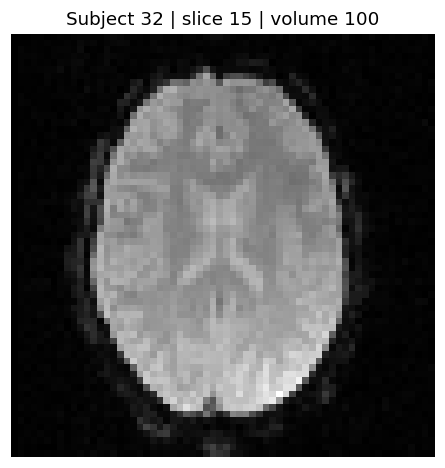

In [36]:
# Choose which slice and which timepoint.
slice_index = 15   # 0 = bottom of the head, 29 = top. 15 is around the middle.
time_index  = 100  # which of the 300 photographs. 100 is somewhere in the middle of the scan.

# data[:, :, 15, 100] means:
#   ":"  -> take ALL of the width
#   ":"  -> take ALL of the height
#   15   -> take only slice 15
#   100  -> take only timepoint 100
# The result is a flat 64 x 64 grid.
one_slice = data[:, :, slice_index, time_index]

print("Shape of what we pulled out:", one_slice.shape, " <- flat 2D image, as expected")

# Create a drawing area. figsize is in inches.
plt.figure(figsize=(5, 5))

# imshow = "image show". It draws a 2D grid as a picture, mapping numbers to colours.
# np.rot90 rotates the image 90 degrees - MRI data is stored in a scanner-based
# orientation that looks sideways, so we rotate it to the familiar upright view.
# cmap="gray" = use a greyscale colour map (low = black, high = white).
plt.imshow(np.rot90(one_slice), cmap="gray")

plt.title(f"Subject {chosen.parent.name} | slice {slice_index} | volume {time_index}")
plt.axis("off")   # hide the pixel-number axes - they add nothing here
plt.show()

That's a horizontal cross-section through a real human head, taken about 3.5 minutes into the
scan.

It's blurry and low-resolution - remember, it's only 64×64 pixels. That is genuinely what
functional MRI looks like. It is built for *speed*, so it can catch activity changing over
seconds, and it trades away spatial detail to get that speed.

## Step 12 - See all 30 slices at once

One slice is one horizontal layer. Let's see the whole stack, bottom to top.

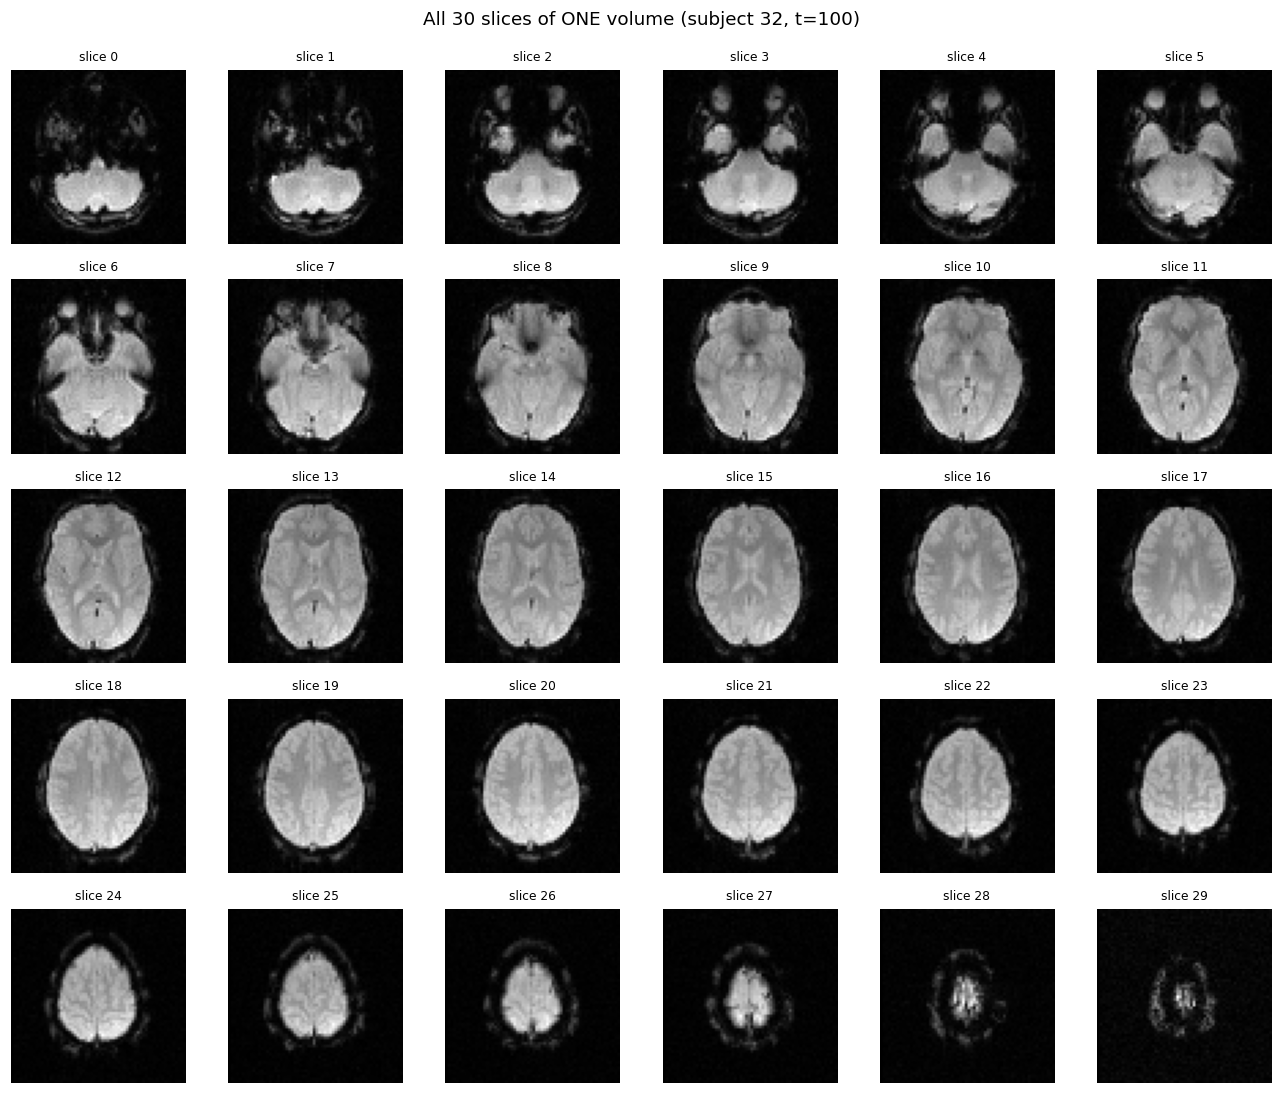

In [37]:
# plt.subplots(rows, cols) creates a grid of small drawing areas at once.
# It returns the whole figure, and an array of the individual axes (sub-plots).
fig, axes = plt.subplots(5, 6, figsize=(12, 10))   # 5 rows x 6 columns = 30 boxes

# axes is a 5x6 grid; .ravel() flattens it into a simple list of 30, easier to loop over.
# enumerate() gives us the slice number z alongside each box.
for z, ax in enumerate(axes.ravel()):
    ax.imshow(np.rot90(data[:, :, z, time_index]), cmap="gray")
    ax.set_title(f"slice {z}", fontsize=8)
    ax.axis("off")

fig.suptitle(f"All 30 slices of ONE volume (subject {chosen.parent.name}, t={time_index})", y=0.99)
plt.tight_layout()   # stops the titles overlapping each other
plt.show()

Read that image bottom-left to top-right. Slice 0 is the bottom of the head - you can see the
cerebellum and the base of the skull. As you move up, the cross-sections get wider through the
middle of the brain, then narrow again at the top of the skull.

**These 30 pictures together are ONE volume - one single training target.** The model's job is to
produce all 30 of these from EEG alone.

Note that slices 0 and 29 are mostly dark. The scanned box is slightly taller than the brain, so
the outer slices catch a lot of empty space.

## Step 13 - The three viewing angles

We've been slicing horizontally. The same 3D box can be cut two other ways. Same data, three
different windows into it.

One volume has shape: (64, 64, 30)


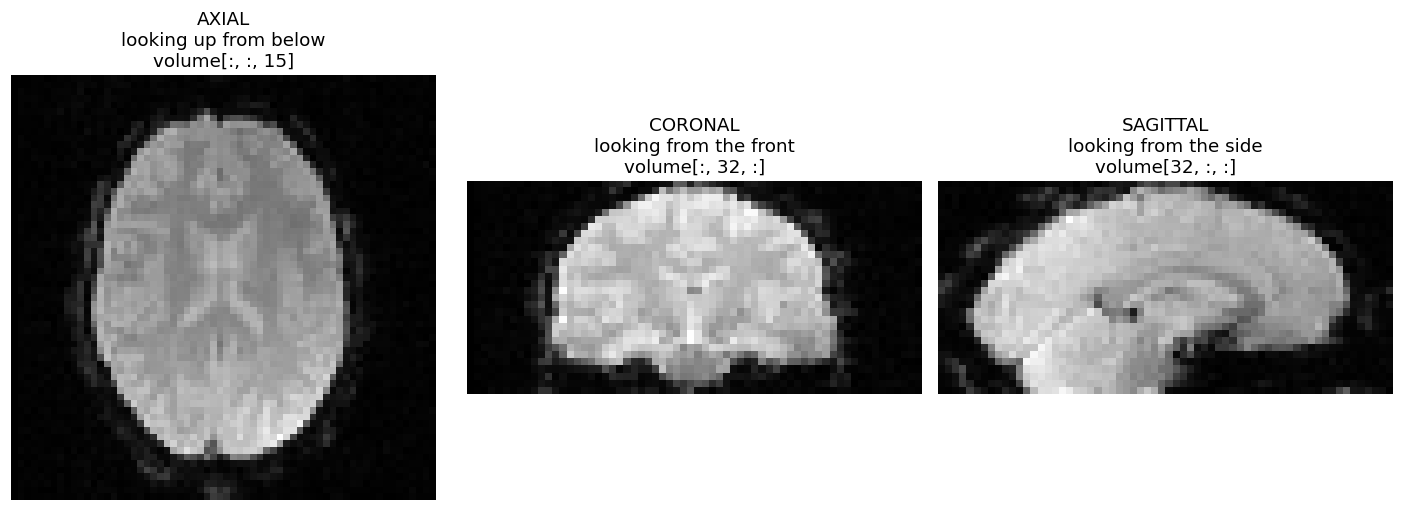

In [38]:
# Grab one complete 3D volume: all width, all height, all slices, at one timepoint.
volume = data[:, :, :, time_index]
print("One volume has shape:", volume.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# AXIAL: cut horizontally. Fix the slice (z), keep width and height.
axes[0].imshow(np.rot90(volume[:, :, 15]), cmap="gray")
axes[0].set_title("AXIAL\nlooking up from below\nvolume[:, :, 15]")

# CORONAL: cut front-to-back. Fix the y position, keep width and slices.
axes[1].imshow(np.rot90(volume[:, 32, :]), cmap="gray")
axes[1].set_title("CORONAL\nlooking from the front\nvolume[:, 32, :]")

# SAGITTAL: cut left-to-right. Fix the x position, keep height and slices.
axes[2].imshow(np.rot90(volume[32, :, :]), cmap="gray")
axes[2].set_title("SAGITTAL\nlooking from the side\nvolume[32, :, :]")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The coronal and sagittal views look stretched and blocky. That's not a bug - it's the voxel
shape. Slices are 3 mm apart but only 30 of them, versus 64 steps of 3.3 mm across. When you cut
along the slice direction you get far fewer samples, so the image looks squashed.

The **sagittal** view (right) is usually the easiest to recognise as a head - you can make out the
profile of the brain and the brain stem.

## Step 14 - What you now know

You opened a real fMRI file and established:

| thing | value | meaning |
|---|---|---|
| shape | `(64, 64, 30, 300)` | 300 volumes, each 64×64×30 voxels |
| voxel size | ~3.3 × 3.3 × 3 mm | one voxel ≈ a million neurons averaged together |
| TR | 2.160 s | a new volume every 2.16 seconds |
| duration | 648 s | a 10.8-minute scan |
| voxels per volume | 122,880 | the size of one prediction target |
| header TR field | wrong (0.072) | always sanity-check headers |

**One volume = 122,880 numbers.** Hold onto that figure. In Part 3 you'll see that the EEG input
for one volume is only 64 numbers per timepoint - and the gap between those two figures is the
central difficulty of this entire project.

---

### Try these before moving on

Small changes, immediate feedback. This is the fastest way to build intuition.

1. In Step 4, change `fmri_files[0]` to `fmri_files[5]`. Re-run from there. Does another person's brain look different?
2. In Step 11, change `slice_index` to `3`, then `25`. What part of the head is each?
3. In Step 11, change `cmap="gray"` to `cmap="hot"` or `cmap="viridis"`. Same data, different colours.
4. In Step 12, change `time_index` to `0` and then `299`. Can you spot any difference between the first and last photograph? (Look at overall brightness - this becomes important in Part 2.)

---

### Coming next

**Part 2 - The time dimension.** We've only looked at frozen snapshots. Part 2 uses the 300
timepoints: what a single voxel's signal looks like as it changes, why the first 6 volumes get
thrown away, and how big the actual brain-activity signal is compared to everything else in that
number. (Spoiler: about 1%.)

Tell me when you're ready and I'll send Part 2.

<br><br>

---
---

<br>

# Part 2 - The time dimension

In Part 1 we froze time. We picked `time_index = 100` and stared at one photograph.

This part is about the **300**. What happens across those 300 photographs, why the first six get
deleted before training, and how small the thing we are actually trying to predict really is.

**Goal of this part:** understand what a voxel's signal looks like over time, and what the repo
does to it before it becomes a training target.

---

### Before you start

Part 2 reuses the variables from Part 1 (`data`, `chosen`, `TR`, and so on). If you ran Part 1 in
this same session, just carry on.

If you closed Jupyter or restarted the kernel, run the cell below to rebuild them. If you did not,
skip it - it is harmless either way but takes a few seconds.

In [39]:
# This cell re-creates everything Part 2 needs, in case you restarted the kernel.
# If Part 1 is still in memory it just reprints the same values.

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path

plt.rcParams["figure.dpi"] = 110

# "try / except" means: attempt the first block, and if it fails, run the second instead.
# NameError is the error Python raises when a variable does not exist.
try:
    data          # just mentioning the name is enough to test whether it exists
    print("Part 1 variables are still loaded. Nothing to do.")
except NameError:
    print("Reloading from disk...")
    DATA_FOLDER = Path(r"E:\EEG_to_FMRI")
    fmri_files  = sorted(DATA_FOLDER.rglob("*_cross.nii.gz"))
    chosen      = fmri_files[0]
    img         = nib.load(chosen)
    data        = img.get_fdata()
    print("Done.")

TR = 2.160   # seconds between volumes - the real value, not the broken header one
print("data shape:", data.shape, "| subject:", chosen.parent.name)

Part 1 variables are still loaded. Nothing to do.
data shape: (64, 64, 30, 300) | subject: 32


## Step 1 - Follow a single voxel through time

Pick one voxel. Ignore all the others. Watch what its number does across the 300 photographs.

This is the fundamental measurement in fMRI. Everything else is built on it.

In [40]:
# Choose one voxel by its 3D position.
x, y, z = 32, 32, 15   # roughly the middle of the box

# data[32, 32, 15, :] means:
#   32  -> this width position
#   32  -> this height position
#   15  -> this slice
#   ":" -> ALL 300 timepoints
# The result is a 1D list of 300 numbers: this voxel's story over the whole scan.
voxel_signal = data[x, y, z, :]

print("Shape of what we pulled out:", voxel_signal.shape, " <- 300 numbers, one per volume")
print()
print("The first 10 values:")
# np.round(..., 1) rounds to 1 decimal place so the output is readable.
print(np.round(voxel_signal[:10], 1))

Shape of what we pulled out: (300,)  <- 300 numbers, one per volume

The first 10 values:
[1325.  962.  925.  929.  909.  891.  918.  897.  926.  928.]


Notice those numbers barely move. They hover around the same value with small wobbles. That is
what a real fMRI voxel looks like: a large, boring baseline with a tiny signal riding on top.

Let's plot it so the shape is visible.

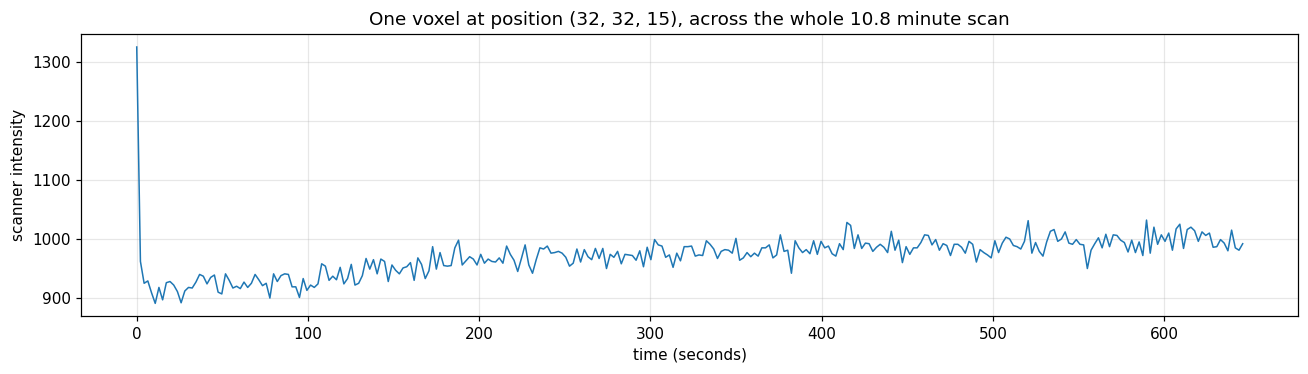

In [41]:
# np.arange(300) makes the list [0, 1, 2, ..., 299].
# Multiplying by TR converts volume numbers into actual seconds.
time_in_seconds = np.arange(len(voxel_signal)) * TR

plt.figure(figsize=(12, 3.5))

# plot(x_values, y_values) draws a line. lw = line width.
plt.plot(time_in_seconds, voxel_signal, lw=1)

plt.xlabel("time (seconds)")
plt.ylabel("scanner intensity")
plt.title(f"One voxel at position ({x}, {y}, {z}), across the whole 10.8 minute scan")

# grid() adds faint reference lines. alpha controls transparency: 0 = invisible, 1 = solid.
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two things to see in that line:

1. **It starts high and drops fast** in the first few seconds, then settles.
2. **After settling it wobbles gently** around a roughly flat level.

That opening drop is not brain activity. It is a scanner artifact, and it is the reason for
`bold_shift = 6` in `data_cfg.py`. We will look at it properly in Step 3.

## Step 2 - Brain voxel versus air voxel

How do we know the wobble is signal and not just noise? Compare against a voxel that contains
nothing at all.

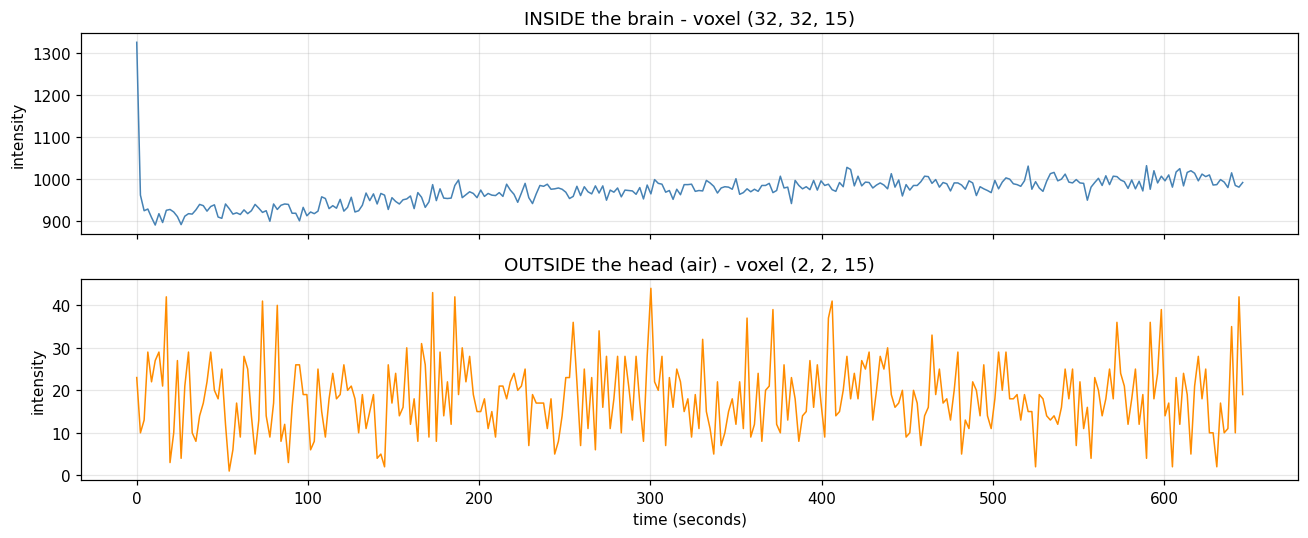

Brain voxel : average    971.0,  wobble (std)  35.24
Air voxel   : average     18.4,  wobble (std)   8.55


In [42]:
# A voxel in the corner of the scanned box - this is air outside the head.
air_signal = data[2, 2, 15, :]

# Draw both on the same figure so the scales are directly comparable.
# subplots(2, 1) = 2 rows, 1 column. sharex=True locks their x-axes together.
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(time_in_seconds, voxel_signal, lw=1, color="steelblue")
axes[0].set_title("INSIDE the brain - voxel (32, 32, 15)")
axes[0].set_ylabel("intensity")
axes[0].grid(alpha=0.3)

axes[1].plot(time_in_seconds, air_signal, lw=1, color="darkorange")
axes[1].set_title("OUTSIDE the head (air) - voxel (2, 2, 15)")
axes[1].set_ylabel("intensity")
axes[1].set_xlabel("time (seconds)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# .mean() and .std() compute the average and the standard deviation (how spread out the values are).
print(f"Brain voxel : average {voxel_signal.mean():8.1f},  wobble (std) {voxel_signal.std():6.2f}")
print(f"Air voxel   : average {air_signal.mean():8.1f},  wobble (std) {air_signal.std():6.2f}")

The air voxel sits near zero with only a little electronic noise. The brain voxel has a real
baseline about 57 times higher, and a wobble roughly 8 times larger. That gap is how you know the
brain voxel is measuring something.

This also tells you something practical: **most of the 122,880 voxels in a volume are empty.**
The scanned box is a cube; a head is not. All those zero voxels still have to be predicted by the
model, and they are trivially easy to get right - which quietly inflates any whole-volume score
like SSIM.

## Step 3 - The first six volumes, and why they are deleted

Instead of one voxel, let's average across the whole brain at each timepoint. Averaging cancels
out random noise and leaves whatever is affecting every voxel at once.

In [43]:
# Step 3a: build a mask - a True/False map of which voxels are inside the head.

# Take the average across time for each voxel, giving one 3D map.
# axis=3 means "collapse dimension 3 (time)".
mean_over_time = data.mean(axis=3)

# np.percentile finds the value below which a given % of the data falls.
# Taking the 60th percentile as a cutoff is a crude but effective "is this brain?" test.
threshold = np.percentile(mean_over_time, 60)

# This comparison produces a 3D grid of True/False - True where the voxel is bright enough.
brain_mask = mean_over_time > threshold

# .sum() counts the Trues (True counts as 1).
print(f"Brightness cutoff       : {threshold:.1f}")
print(f"Voxels marked as brain  : {brain_mask.sum():,} out of {brain_mask.size:,}")
print(f"That is {100*brain_mask.sum()/brain_mask.size:.0f}% of the box")

Brightness cutoff       : 62.0
Voxels marked as brain  : 49,151 out of 122,880
That is 40% of the box


In [44]:
# Step 3b: for each of the 300 volumes, average only the voxels inside the mask.

# A "list comprehension" - a compact for-loop that builds a list.
# Read it as: for each timepoint t, take volume t, keep only the masked voxels, average them.
global_signal = np.array([data[:, :, :, t][brain_mask].mean() for t in range(data.shape[3])])

print("Shape:", global_signal.shape, " <- one average brightness per volume")
print()
print("First 10 volumes:", np.round(global_signal[:10], 1))
print("Volumes 100-109 :", np.round(global_signal[100:110], 1))

Shape: (300,)  <- one average brightness per volume

First 10 volumes: [847.3 697.1 685.9 684.6 682.8 682.7 683.3 683.6 684.1 685. ]
Volumes 100-109 : [685.4 685.3 685.5 684.9 684.8 685.7 685.9 684.8 685.1 685.5]


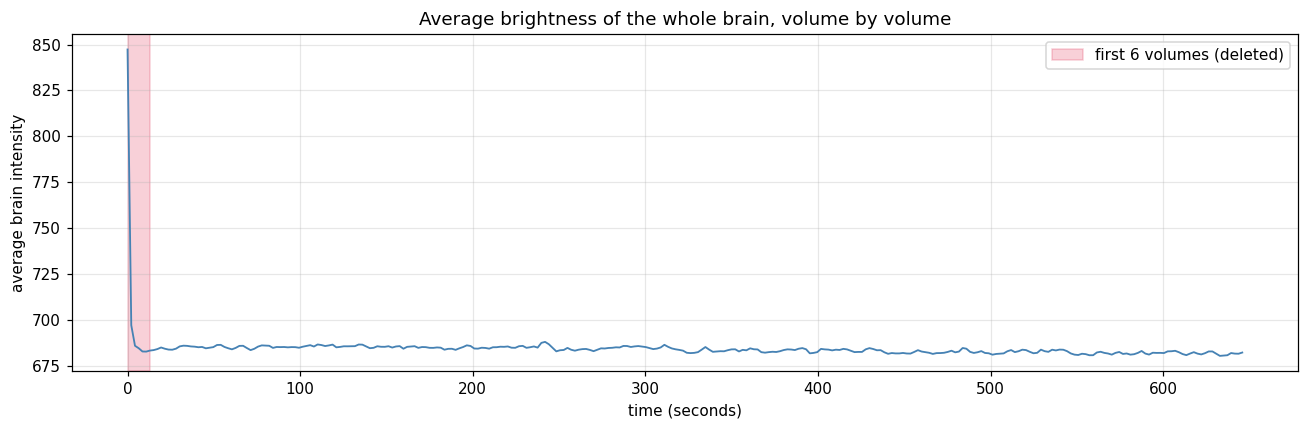

Volume 0 is 23.6% brighter than volume 20.


In [45]:
plt.figure(figsize=(12, 4))

plt.plot(time_in_seconds, global_signal, lw=1.2, color="steelblue")

# axvspan shades a vertical band, from x1 to x2. We shade the first 6 volumes.
plt.axvspan(0, 6*TR, color="crimson", alpha=0.2, label="first 6 volumes (deleted)")

plt.xlabel("time (seconds)")
plt.ylabel("average brain intensity")
plt.title("Average brightness of the whole brain, volume by volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify the size of the drop.
drop = 100 * (global_signal[0] - global_signal[20]) / global_signal[20]
print(f"Volume 0 is {drop:.1f}% brighter than volume 20.")

### What that spike is

The first few volumes are much brighter than everything after them, and it has nothing to do with
the brain.

An MRI scanner works by knocking hydrogen atoms out of alignment with a radio pulse and listening
as they realign. At the very start of a scan, every hydrogen atom in the head is fully aligned and
fully "fresh", so the first pulse gets an unusually strong response. After a few pulses the atoms
reach a steady back-and-forth rhythm and the signal levels off.

This is called **T1 saturation**, or the approach to **steady state**. It is a property of physics,
not of the person in the scanner.

Those early volumes are unusable. They are far brighter than everything else, so leaving them in
would distort any normalisation you apply afterwards. Every fMRI pipeline in existence throws away
the first handful.

In this repo it is one line in `data_cfg.py`:

```python
'bold_shift': 6,
```

and in `utils.py`:

```python
fmri_data = fmri_data[:, :, :, bold_shift : recording_time + bold_shift]
```

**300 volumes minus 6 = 294.** That is the `n_volumes: 294` you see in the config, with the
comment `# 300 - bold_shift`.

In [46]:
# Prove the cut to yourself.
BOLD_SHIFT = 6
n_volumes  = 294

trimmed = data[:, :, :, BOLD_SHIFT : n_volumes + BOLD_SHIFT]

print("Before trimming :", data.shape)
print("After trimming  :", trimmed.shape)
print()
print(f"We kept volumes {BOLD_SHIFT} to {BOLD_SHIFT + n_volumes - 1}, which is {n_volumes} volumes.")

Before trimming : (64, 64, 30, 300)
After trimming  : (64, 64, 30, 294)

We kept volumes 6 to 299, which is 294 volumes.


## Step 4 - How big is the actual brain signal?

Now the uncomfortable number. Take a settled brain voxel (after the spike) and ask: how much does
it actually vary?

In [47]:
# Skip the first 6 volumes so the T1 spike does not distort the statistics.
settled = voxel_signal[BOLD_SHIFT:]

average = settled.mean()
wobble  = settled.std()

print(f"Average value of this voxel : {average:.1f}")
print(f"Standard deviation (wobble) : {wobble:.2f}")
print()

# Percent signal change: the wobble expressed as a fraction of the baseline.
percent = 100 * wobble / average
print(f"The wobble is {percent:.2f}% of the baseline.")
print()
print("And that wobble is not all brain activity. It also contains:")
print("  - thermal noise from the scanner electronics")
print("  - the person breathing (chest movement shifts the magnetic field)")
print("  - the person's heartbeat")
print("  - tiny head movements")
print()
print("The genuine task-related BOLD signal is a fraction of a fraction of one percent.")

Average value of this voxel : 970.6
Standard deviation (wobble) : 28.16

The wobble is 2.90% of the baseline.

And that wobble is not all brain activity. It also contains:
  - thermal noise from the scanner electronics
  - the person breathing (chest movement shifts the magnetic field)
  - the person's heartbeat
  - tiny head movements

The genuine task-related BOLD signal is a fraction of a fraction of one percent.


### Sit with this for a moment

**Around 98% of the number stored in each voxel is baseline that has nothing to do with brain
activity.**

The thing the model is trying to predict is that last sliver. This is the honest reason why SSIM
around 0.7 is a strong result in this field rather than a disappointing one: a model that
reproduces the anatomy correctly and gets the activity slightly wrong still scores well, because
anatomy is over 99% of the picture.

When you write your report, this is the number to quote if someone asks why the reconstructions
"look right but do not carry much information".

## Step 5 - Why fMRI lags behind the brain by about 6 seconds

A quick detour into what BOLD actually measures, because it explains a design choice you will meet
in Part 5.

fMRI does not measure electrical activity. It measures **blood oxygen level dependent** signal -
literally, how oxygenated the blood in a voxel is.

The chain of events is:

1. Neurons fire. This is electrical, and it happens in **milliseconds**.
2. Those neurons use up oxygen.
3. The body notices and sends extra oxygenated blood to the area.
4. The blood-oxygen ratio changes, which changes the magnetic properties of the blood.
5. The scanner detects that change.

Steps 3 to 5 are a plumbing response, and plumbing is slow. The peak arrives roughly **5 to 6
seconds** after the neurons fired, and it is smeared out over about 15 seconds.

The shape of that delayed response is called the **haemodynamic response function**, or HRF.

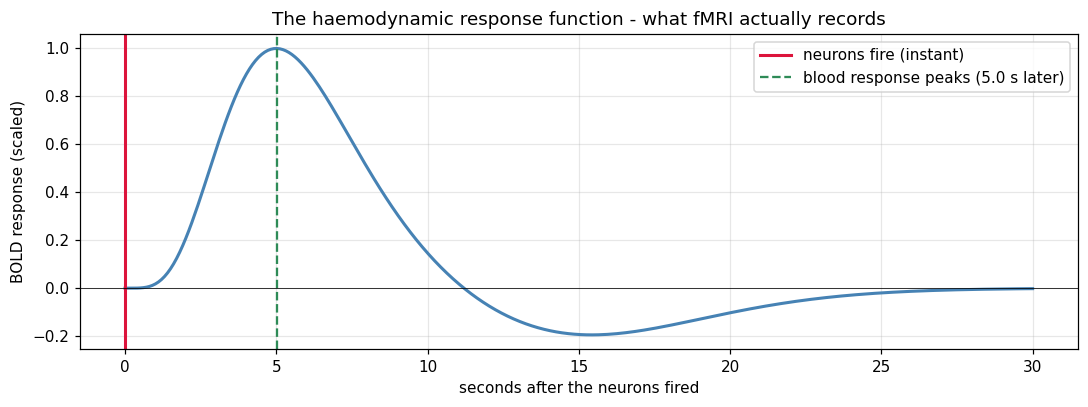

Peak delay: 5.0 seconds
In TR units: 2.3 volumes after the event


In [48]:
from scipy.stats import gamma

# Build a textbook HRF so you can see its shape. This is a standard two-gamma model:
# one gamma curve for the main rise-and-fall, minus a smaller, slower one for the undershoot.
t = np.linspace(0, 30, 300)                      # 30 seconds, sampled finely
hrf = gamma.pdf(t, 6) - 0.35 * gamma.pdf(t, 16)  # the classic double-gamma shape
hrf = hrf / hrf.max()                            # scale so the peak is exactly 1.0

plt.figure(figsize=(10, 3.8))
plt.plot(t, hrf, lw=2, color="steelblue")

# Mark the instant of neural firing.
plt.axvline(0, color="crimson", lw=2, label="neurons fire (instant)")

# Mark where the blood response peaks.
peak_time = t[hrf.argmax()]   # argmax gives the position of the largest value
plt.axvline(peak_time, color="seagreen", ls="--", lw=1.5,
            label=f"blood response peaks ({peak_time:.1f} s later)")

plt.axhline(0, color="black", lw=0.5)
plt.xlabel("seconds after the neurons fired")
plt.ylabel("BOLD response (scaled)")
plt.title("The haemodynamic response function - what fMRI actually records")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak delay: {peak_time:.1f} seconds")
print(f"In TR units: {peak_time/TR:.1f} volumes after the event")

So EEG sees the electrical event immediately, and fMRI sees a blurred echo of it about 5
seconds later.

This is why the pipeline does not pair "EEG at time t" with "volume at time t". In Part 5 you will
see it uses **20 TRs of EEG history** (about 43 seconds) to predict a single volume. That window
has to be long enough to contain the neural events whose blood response is only now showing up.

A useful reframe: the model is not translating between two views of the same instant. It is
predicting a delayed, smeared consequence from its cause.

## Step 6 - The normalisation the repo applies

Raw scanner intensities are meaningless in absolute terms - a value of 2226 is not "more brain"
than 1800 on a different scanner, or even a different day. So everything gets rescaled to the
range 0 to 1 before training.

**How** it rescales matters more than you would expect. Here is the exact code from
`utils.get_data_NODDI`:

```python
min_vals = np.min(fmri_data, axis=(0, 1, 2), keepdims=True)
max_vals = np.max(fmri_data, axis=(0, 1, 2), keepdims=True)
fmri_data = (fmri_data - min_vals) / (max_vals - min_vals + 1e-10)
```

`axis=(0, 1, 2)` means: find the min and max across width, height and slices - but **separately
for each timepoint**. So each of the 294 volumes is scaled by its own min and max.

In [49]:
# Reproduce it exactly.

# keepdims=True keeps the collapsed dimensions as size 1, so the subtraction below
# broadcasts correctly across every voxel of each volume.
min_vals = np.min(trimmed, axis=(0, 1, 2), keepdims=True)
max_vals = np.max(trimmed, axis=(0, 1, 2), keepdims=True)

print("Shape of min_vals:", min_vals.shape, " <- one min per volume, 294 of them")
print()
print("Min of the first 5 volumes:", np.round(min_vals.ravel()[:5], 1))
print("Max of the first 5 volumes:", np.round(max_vals.ravel()[:5], 1))
print()

# The 1e-10 is a guard: it stops a division by zero if a volume were completely flat.
normalised = (trimmed - min_vals) / (max_vals - min_vals + 1e-10)

print("After normalising:")
print("  shape :", normalised.shape)
print(f"  range : {normalised.min():.4f} to {normalised.max():.4f}")

Shape of min_vals: (1, 1, 1, 294)  <- one min per volume, 294 of them

Min of the first 5 volumes: [0. 0. 0. 0. 0.]
Max of the first 5 volumes: [1585. 1593. 1593. 1589. 1587.]

After normalising:
  shape : (64, 64, 30, 294)
  range : 0.0000 to 1.0000


### The consequence

Because each volume is scaled by **its own** min and max, every single volume ends up with exactly
one voxel at 0.0 and one at 1.0.

This is worth understanding rather than just accepting, because it shapes how you should read the
results:

- The 0.0 voxel is always somewhere in the air outside the head.
- Absolute brightness differences **between** volumes are erased. If the whole brain got 5%
  brighter, normalisation removes that. Only the pattern within each volume survives.
- The model never has to learn overall scale, only relative structure.

An alternative would have been to scale the entire 4D run by one global min and max, preserving
between-volume differences. The repo does not do that. Neither choice is wrong, but they measure
different things, and if you compare your numbers to another paper you need to know which one that
paper used.

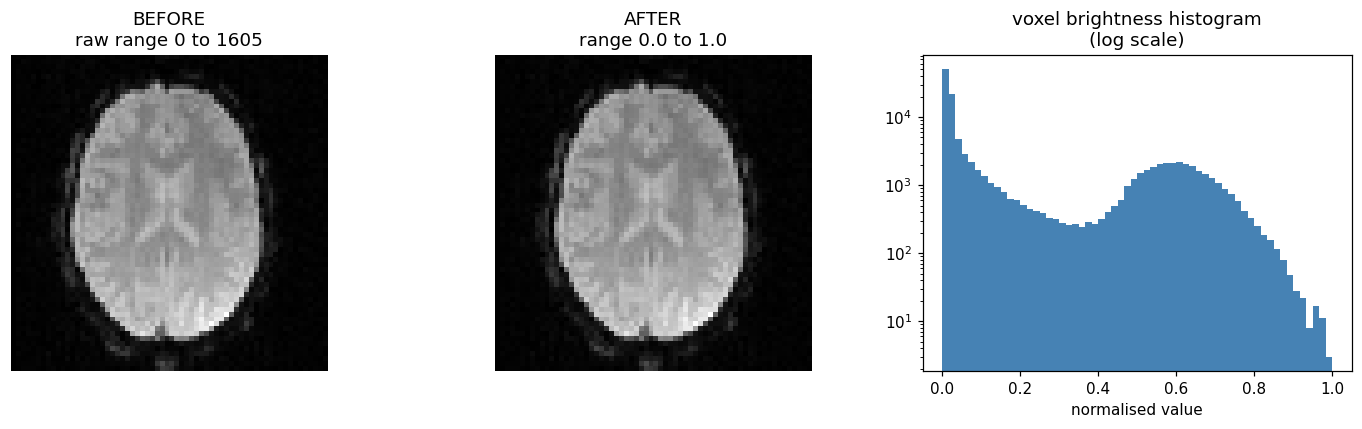

The two brain images look identical - and they should. Normalisation only
relabels the numbers; it does not change the pattern.

The histogram is the interesting one: that huge spike at 0 is all the empty
air voxels. Most of the scanned box is not brain at all - our mask in Step 3
marked only about 40% of it as head.


In [50]:
# See the effect of normalisation on one slice.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

t_show = 100

axes[0].imshow(np.rot90(trimmed[:, :, 15, t_show]), cmap="gray")
axes[0].set_title(f"BEFORE\nraw range {trimmed[:,:,:,t_show].min():.0f} to {trimmed[:,:,:,t_show].max():.0f}")
axes[0].axis("off")

axes[1].imshow(np.rot90(normalised[:, :, 15, t_show]), cmap="gray")
axes[1].set_title(f"AFTER\nrange {normalised[:,:,:,t_show].min():.1f} to {normalised[:,:,:,t_show].max():.1f}")
axes[1].axis("off")

# hist() draws a histogram - how many voxels fall into each brightness band.
# .ravel() flattens the 3D volume into a plain list of numbers so hist can count them.
axes[2].hist(normalised[:, :, :, t_show].ravel(), bins=60, color="steelblue")
axes[2].set_yscale("log")   # log scale, or the huge zero-spike hides everything else
axes[2].set_title("voxel brightness histogram\n(log scale)")
axes[2].set_xlabel("normalised value")

plt.tight_layout()
plt.show()

print("The two brain images look identical - and they should. Normalisation only")
print("relabels the numbers; it does not change the pattern.")
print()
print("The histogram is the interesting one: that huge spike at 0 is all the empty")
print("air voxels. Most of the scanned box is not brain at all - our mask in Step 3")
print("marked only about 40% of it as head.")

## Step 7 - Which voxels actually carry information?

Not every voxel is equally worth predicting. Some barely change across the whole scan; others move
a lot. A map of variability tells you where the usable signal lives.

Variability map shape: (64, 64, 30)  <- one number per voxel, no time


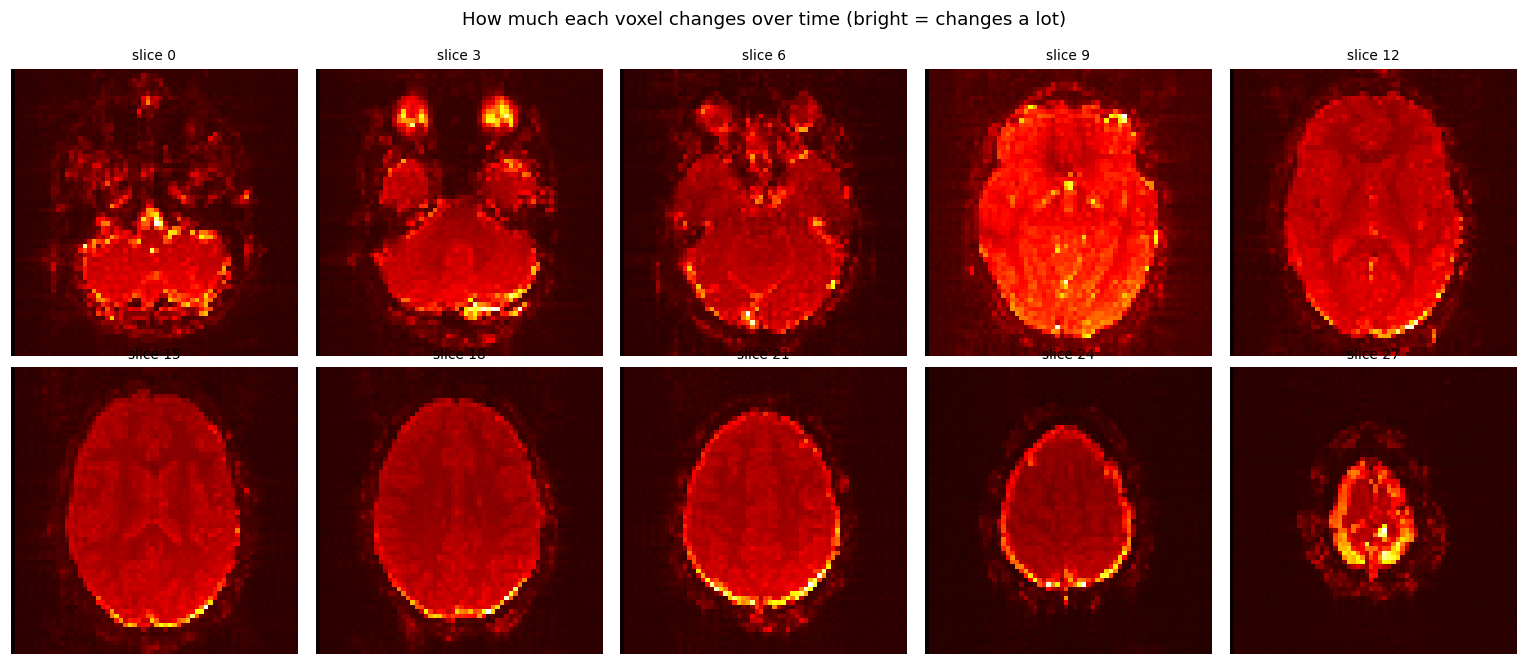

In [51]:
# Standard deviation across time, for every voxel. axis=3 collapses the time dimension.
variability = normalised.std(axis=3)

print("Variability map shape:", variability.shape, " <- one number per voxel, no time")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.ravel()):
    z = i * 3   # show every third slice: 0, 3, 6, ... 27
    im = ax.imshow(np.rot90(variability[:, :, z]), cmap="hot")
    ax.set_title(f"slice {z}", fontsize=9)
    ax.axis("off")

fig.suptitle("How much each voxel changes over time (bright = changes a lot)", y=1.0)
plt.tight_layout()
plt.show()

Bright areas are where the signal moves. Notice that a lot of the brightest regions sit at the
**edges of the brain** and around the ventricles, not in the middle of grey matter.

That is mostly head motion and pulsation, not thought. When a head shifts by half a millimetre,
the voxels at a tissue boundary swing between two very different tissue types, so they change a
lot. Interior voxels stay surrounded by the same tissue and change little.

This is a standard trap in reading fMRI variance maps, and it is worth naming in your report: high
variance does not mean high information.

## Step 8 - What you now know

| thing | value | why it matters |
|---|---|---|
| voxel baseline | ~2200 | arbitrary units, no physical meaning |
| voxel wobble | ~1% of baseline | the signal is tiny compared to what it rides on |
| T1 saturation | first ~6 volumes | why `bold_shift = 6` exists |
| volumes after trim | 294 | the `n_volumes` in `data_cfg.py` |
| BOLD peak delay | ~5 s after firing | why the model needs a long EEG history window |
| normalisation | per volume, min-max to 0-1 | every volume gets exactly one 0.0 and one 1.0 |
| empty voxels | ~60% of the box | trivially easy to predict, quietly inflates SSIM |

The two ideas to carry forward:

1. **The signal is about 1% of the number.** Everything else is anatomy and noise. This is the
   honest framing for your results section.
2. **fMRI lags its cause by about 5 seconds.** This is why the input is a long window of EEG
   history rather than a single instant.

---

### Try these before moving on

1. In Step 1, change `x, y, z` to `10, 10, 5`. That is near the edge of the head. How does the line differ?
2. In Step 3, change the percentile from `60` to `85`. Does the mask get tighter? Does the T1 spike look different?
3. In Step 4, try a few voxels and see how much the percent-change figure varies. Is 1% typical?
4. In Step 6, change `t_show` to `0`. This is a volume we deleted. Compare its raw range to volume 100's - can you see the T1 spike in the numbers?

---

### Coming next

**Part 3 - The EEG file.** A completely different kind of data: 64 electrodes recording voltage
250 times a second. We will open one with MNE, look at what a raw brain wave actually looks like,
and find the two surprises hiding in the header. Then Part 4 turns those waves into the
spectrogram pictures the model actually eats.

Tell me when you are ready and I will append Part 3 to this same file.